# Same anomaly but different scores

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx
from anomaly.utils import get_sdss_spec_img

from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [2]:
def load_xai(n_segments: int, run_ids: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Plot 5X2 explanations

In [4]:
def plot_same_anomaly_explanations(
    data: dict,
    wave_nm: np.ndarray,
    image: np.ndarray,
    line_configs: dict,
    spec_y_config: dict,
    xai_config: dict = {"y_lim": (0, 1.35), "y_ticks": [0, 0.5, 1]},
    text_dict={"x": 0.01, "y": 0.9, "ha": "left", "va": "center"},
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    figsize=(14, 3.5*3),
    lw_dict: dict = {"spec": 0.75, "xai": 0.75},
):

    spectrum = data["spectrum"]

    fig, axs = plt.subplots(6, 2, sharex=True, figsize=figsize)
    spec_ylim = spec_y_config["ylim"]
    spec_yticks = spec_y_config.get("yticks", None)
    # Map the scores to their respective rows and columns
    scores_layout = [
        ("SE", "RSE"),  # Row 1
        ("Filter SE", "Filter RSE"),  # Row 2
        ("Trim SE", "Trim RSE"),  # Row 3
        ("Filter + Trim SE", "Filter + Trim RSE"),  # Row 4
        ("LOF", "iForest"),  # Row 5
    ]

    # =================================================================================
    # Plot Row 0: Original Spectrum (Both Columns)
    # =================================================================================
    for c in [0, 1]:

        axs[0, c], _ = spec_photo_thumbnail(
            axs[0, c],
            wave_nm,
            spectrum,
            image,
            add_image=True,
            bbox_to_anchor=bbox_to_anchor,
            lw=lw_dict["spec"],
        )
        axs[0, c].set_ylim(spec_ylim)
        if spec_yticks is not None:
            axs[0, c].set_yticks(spec_yticks)
        axs[0, c].minorticks_on()

        if c == 0:
            axs[0, c].set_ylabel("Flux")
        else:
            axs[0, c].tick_params(labelleft=False)

        if line_configs.get("spectrum", {}).get("active_lines"):
            add_line_indicators(
                axs[0, c], wave_nm, spectrum, **line_configs["spectrum"]
            )

    # ================================================================================
    # Rows 1-4: Explanations
    # ================================================================================
    for i, (score_se_lof, score_rse_iforest) in enumerate(scores_layout):
        # Offset by 1 because Row 0 is the spectrum
        r = i + 1
        # Iterate through Col 0 (SE+lof) and Col 1 (RSE+iforest)
        for c, score_name in enumerate((score_se_lof, score_rse_iforest)):

            axs[r, c], _ = spec_photo_thumbnail(
                axs[r, c], wave_nm, data[score_name], add_image=False, lw=lw_dict["xai"]
            )

            axs[r, c].set_ylim(xai_config["y_lim"])
            axs[r, c].set_yticks(xai_config["y_ticks"])
            axs[r, c].minorticks_on()
            axs[r, c].text(
                text_dict["x"],
                text_dict["y"],
                score_name,
                ha=text_dict["ha"],
                va=text_dict["va"],
                transform=axs[r, c].transAxes,
            )

            if c == 0:
                axs[r, c].set_ylabel("Weights")
            else:
                axs[r, c].tick_params(labelleft=False)

            # Fetch the specific config for this score_name
            # If it doesn't exist in the dictionary, returns an empty dict {}
            current_config = line_configs.get(score_name, {})

            if current_config.get("active_lines"):
                add_line_indicators(
                    axs[r, c], wave_nm, data[score_name], **current_config
                )

    # ================================================================================
    # Global Axes Settings
    # ================================================================================
    wave_ticks = list(np.arange(400, 751, 50))
    for col in [0, 1]:
        axs[5, col].set_xlim(350, 770)
        axs[5, col].set_xticks(wave_ticks)
        axs[5, col].set_xlabel(r"$\lambda$ [nm]")
    return fig, axs

# Config

## Constants

### score map

In [5]:
score_name_map = {
    "mse": "SE",
    "mse_filter_250": "Filter SE",
    "mse_97": "Trim SE",
    "mse_filter_250_97": "Filter + Trim SE",
    "mse_rel": "RSE",
    "mse_filter_250_rel": "Filter RSE",
    "mse_97_rel": "Trim RSE",
    "mse_filter_250_97_rel": "Filter + Trim RSE",
    "lof": "LOF",
    "iforest": "iForest"
}

### run ids 221

In [6]:
run_ids_221_dict = {
    "mse": "xai_202607061319_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250": "xai_202607061811_uniform_221_samples_50000_scale_0.9",
    "mse_97": "xai_202607061937_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97": "xai_202607062045_uniform_221_samples_50000_scale_0.9",
    # ----
    "mse_rel": "xai_202607062150_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_rel": "xai_202607070126_uniform_221_samples_50000_scale_0.9",
    "mse_97_rel": "xai_202607062313_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97_rel": "xai_202607071050_uniform_221_samples_50000_scale_0.9",
    # ----
    'lof': 'xai_202606221052_uniform_221_samples_50000_scale_0.9',
    'iforest': 'xai_202606222135_uniform_221_samples_50000_scale_0.9',
}

### run ids 243

In [7]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ---
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ----
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9',
}

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
explanations_dir = f"{data_dir}/explanations"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

## Meta data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"

## LOF and iForest scores

In [10]:
lof_score_name = "lof_scores_bin_03_n60_manhattan.csv"
lof_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/lof/{lof_score_name}", index_col="specobjid"
)
# map rank col to lof_rank
lof_scores_df.rename(columns={"rank": "rank_lof"}, inplace=True)

iforest_score_name = "iforest_scores_bin_03_s128_e300_f100.csv"
iforest_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/iforest/{iforest_score_name}", index_col="specobjid"
)

# map rank col to iforest_rank
iforest_scores_df.rename(
    columns={"rank": "rank_iforest", "iforest_score": "iforest"}, inplace=True
)

## Common ids to all scores

In [11]:
common_ids_arr = np.load(
    f"{explanations_dir}/bin_03/common_ids_all_scores.npy", mmap_mode="r"
)

# Explanations

In [12]:
bin_id = "bin_03"
n_segments = 343

if n_segments == 221:
    run_ids_dict = run_ids_221_dict
elif n_segments == 343:
    run_ids_dict = run_ids_343_dict

anomalies_all_dict = {}
specids_all_dict = {}
weights_all_dict = {}

for score_name, run_id in run_ids_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(n_segments=n_segments, run_ids=run_id, load_from=load_from)

    anomalies_all_dict[score_name] = anomalies_arr
    specids_all_dict[score_name] = specobjids_arr
    weights_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

In [13]:
np.sum(weights_all_dict['iforest']['norm_weights'][0]**2)

np.float32(1.0000001)

# Figures all common

## Load weights
```python
bin_id = "bin_03"

all_common_dict = {}

for objid in common_ids_list:
    rank_lof = lof_scores_df.loc[objid, "rank_lof"]
    rank_lof = f"{rank_lof:04d}"
    all_common_dict[rank_lof] = objid

spec_all_common_dict = {}
# dict with all explanations: xai_common_dict[anomaly_name][score_name] = weights
xai_all_common_dict = {}

print("Get specs and load photometry")

save_to = "/home/elom/Downloads/xai_common"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for anomaly_name, specobjid in all_common_dict.items():

    # print(f"Processing anomaly: {anomaly_name}")
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)

    xai_all_common_dict[anomaly_name] = {}
    xai_all_common_dict[anomaly_name]["spectrum"] = spectra[idx_spectrum]

    for metric, score_name in score_name_map.items():

        idx_mask = specids_all_dict[metric] == specobjid

        _weights = weights_all_dict[metric]["norm_weights"][idx_mask][0]
        xai_all_common_dict[anomaly_name][score_name] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[specobjid].values
    # get_sdss_spec_img(
    #     specobjid=specobjid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_all_common_dict = {}

for key in all_common_dict.keys():

    objid = all_common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_all_common_dict[key] = img_

```

## Create plots
```python
save_dir = f"/home/elom/Downloads/unit_xai_common_{n_segments}"
os.makedirs(save_dir, exist_ok=True)
xai_config = {"y_lim": (0, 0.35), "y_ticks": [0, 0.1, 0.2, 0.3]}

for anomaly_name, specobjid in all_common_dict.items():
    plt.ioff()
    data = xai_all_common_dict[anomaly_name]
    spectrum = data["spectrum"]
    image = img_all_common_dict[anomaly_name]
    spec_ylim = None
    spec_yticks = None
    lw_dict: dict = {"spec": 0.75, "xai": 0.75}
    # Base configuration for explanations
    base_exp_config = {
        "indicator_starts": 0.06,
        "indicator_height": 0.07,
        "delta": 1,
        "fontsize": 6.5,
    }
    # lines to the spectrum and to each score
    line_configs = {
        "spectrum": {
            "indicator_starts": 5,
            "indicator_height": 5,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [],
        },
        # line indicators for explanations
        "SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Trim SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter + Trim SE": {
            **base_exp_config,
            "active_lines": [],
        },
        "LOF": {**base_exp_config, "active_lines": [""]},
        "RSE": {**base_exp_config, "active_lines": [""]},
        "Filter RSE": {**base_exp_config, "active_lines": []},
        "Trim RSE": {
            **base_exp_config,
            "active_lines": [],
        },
        "Filter + Trim RSE": {
            **base_exp_config,
            "active_lines": [],
        },
        "iForest": {**base_exp_config, "active_lines": []},
    }

    fig, axs = plot_same_anomaly_explanations(
        data=data,
        wave_nm=wave_nm,
        image=image,
        line_configs=line_configs,
        spec_ylim=spec_ylim,
        spec_yticks=spec_yticks,
        xai_config=xai_config,
        lw_dict=lw_dict,
    )

    fname = f"{anomaly_name}_{specobjid}.jpeg"
    plt.subplots_adjust(hspace=0.06, wspace=0.02)

    fig.savefig(f"{save_dir}/{fname}", bbox_inches="tight")
    plt.close(fig)
```

# Data prep selected anomaly

In [14]:
bin_id = "bin_03"
# key corresponds to lof rank
common_dict = {"0044": 561847176611784704}

spec_common_dict = {}
# dict with all explanations: xai_common_dict[anomaly_name][score_name] = weights
xai_common_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/common_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for anomaly_name, specobjid in common_dict.items():

    print(f"Processing anomaly: {anomaly_name}")
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)

    xai_common_dict[anomaly_name] = {}
    xai_common_dict[anomaly_name]["spectrum"] = spectra[idx_spectrum]

    for metric, score_name in score_name_map.items():

        idx_mask = specids_all_dict[metric] == specobjid

        _weights = weights_all_dict[metric]["norm_weights"][idx_mask][0]
        xai_common_dict[anomaly_name][score_name] = _weights

    # download image and spectrum
    # verify if file already exists before downloading
    fname_img = f"{save_to}/image_{specobjid}.jpeg"
    if not os.path.exists(fname_img):
        ra, dec = final_meta_df[['ra', 'dec']].loc[specobjid].values
        get_sdss_spec_img(
            specobjid=specobjid, ra=ra, dec=dec, save_to=save_to
        )

# Load photometry
img_common_dict = {}

for key in common_dict.keys():

    objid = common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_common_dict[key] = img_

Get specs and load photometry
Processing anomaly: 0044


## Figure

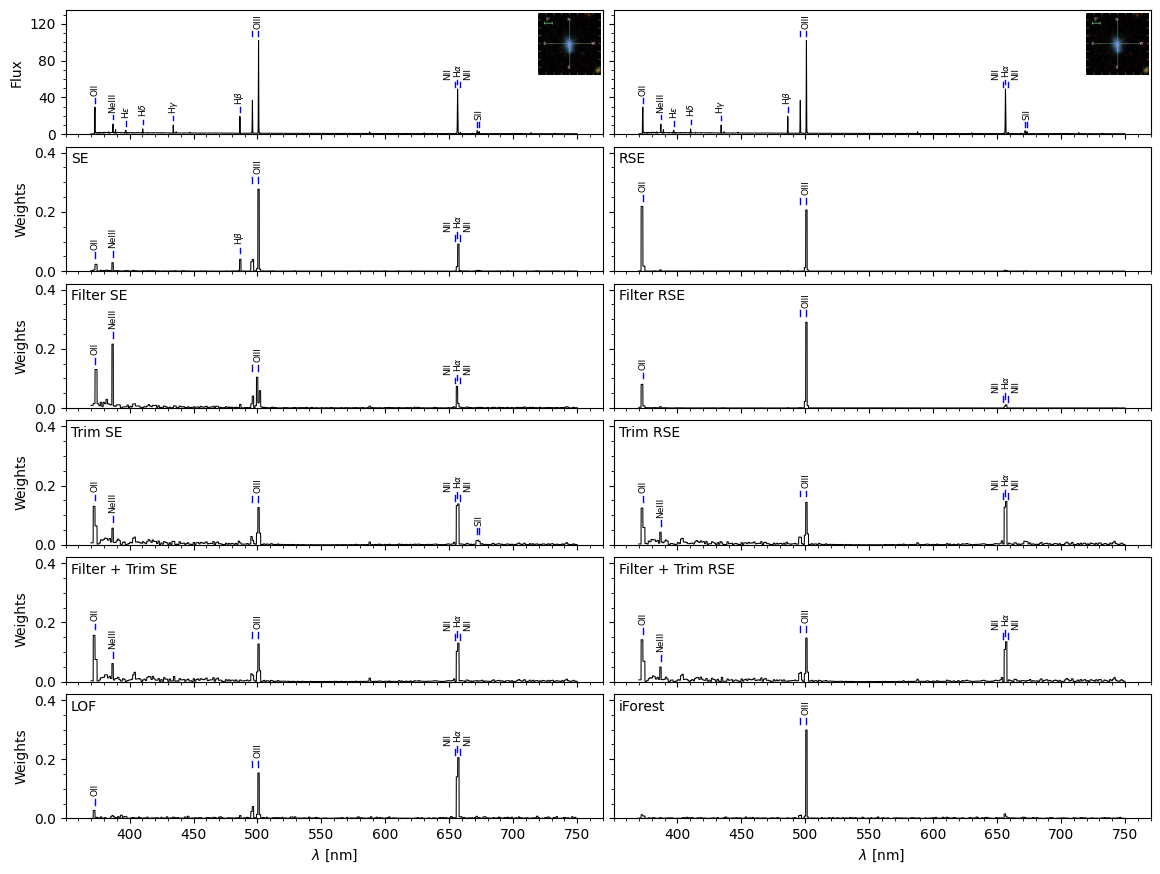

In [20]:
anomaly_name = "0044"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
xai_config = {"y_lim": (0, 0.42), "y_ticks": [0, 0.2, 0.4]}
spec_y_config = {"ylim": (0, 135), "yticks": range(0, 121, 40)}
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.02,
    "indicator_height": 0.02,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII", "NeIII", "H_epsilon", "H_delta", "H_gamma", "H_beta",
            "OIII", "H_alpha", "SII"
        ],
    },
    # line indicators for explanations
    "SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "H_beta", "OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "LOF": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"]
    },
    "RSE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII"]}
    ,
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"]
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "iForest": {**base_exp_config, "active_lines": ["OIII"]},
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_y_config=spec_y_config,
    lw_dict=lw_dict,
    image=image,
    xai_config=xai_config,
    bbox_to_anchor=(0.7, 0.53, 0.5, 0.5)
)

plt.subplots_adjust(hspace=0.1, wspace=0.02)
# save fig
# fig.savefig(f"{ch_5_dir}/common_xai_{anomaly_name}.pdf", bbox_inches="tight")

# Anomaly plot

In [21]:
anomaly_name = "0044"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

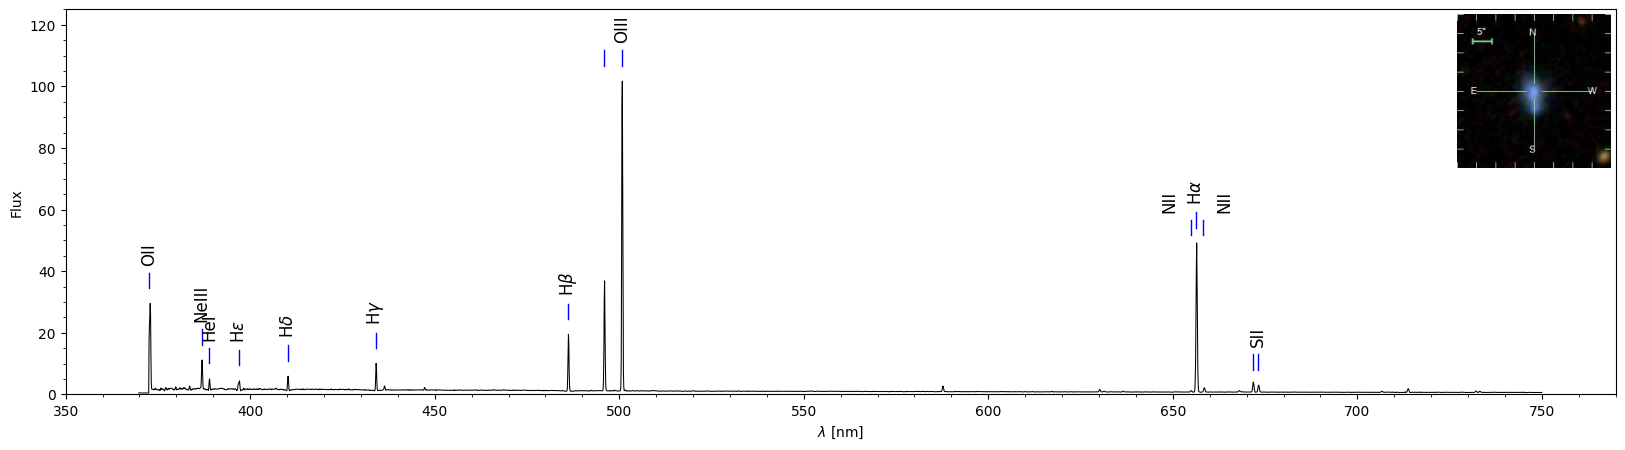

In [23]:
fig, ax = plt.subplots(figsize=(20, 5))
# -------------------------------------------------------------------------------------
spec_config = {
    "ylim": (0, 125),
    "yticks": range(0, 121, 20),
    "bbox_to_anchor": (0.752, 0.605, 0.4, 0.4),
    'lw': 0.75
}
# -------------------------------------------------------------------------------------
line_configs = {
    "indicator_starts": 5,
    "indicator_height": 5,
    "delta": 1,
    "fontsize": 12,
    "active_lines": [
        "OII", "NeIII", "HeI", "H_epsilon", "H_delta", "H_gamma", "H_beta",
        "OIII", "H_alpha", "SII"
    ],
}
# -------------------------------------------------------------------------------------
ax, _ = spec_photo_thumbnail(
    ax,
    wave_nm,
    spectrum,
    image,
    add_image=True,
    lw=spec_config['lw'],
    bbox_to_anchor=spec_config['bbox_to_anchor']
)
# -------------------------------------------------------------------------------------
# Add line indicators
add_line_indicators(ax, wave_nm, spectrum, **line_configs)
# -------------------------------------------------------------------------------------
ax.set_ylabel("Flux")
ax.set_ylim(spec_config['ylim'])
ax.set_yticks(spec_config['yticks'])
wave_ticks = list(np.arange(350, 751, 50))
ax.set_xlim(350, 770)
ax.set_xticks(wave_ticks)
ax.set_xlabel(r"$\lambda$ [nm]")
ax.minorticks_on()

# fig.savefig(f"{ch_5_dir}/universal_{anomaly_name}.pdf", bbox_inches="tight")

# Anomaly weights

In [47]:
lines_mask = {
    "OII_mask": (wave_nm >= 370) & (wave_nm <= 380),
    "NeIII_mask": (wave_nm >= 385) & (wave_nm <= 390),
    "H_epsilon_mask": (wave_nm >= 395) & (wave_nm <= 400),
    "H_delta_mask": (wave_nm >= 407) & (wave_nm <= 413),
    "H_gamma_mask": (wave_nm >= 430) & (wave_nm <= 440),
    "H_beta_mask": (wave_nm >= 485) & (wave_nm <= 490),
    "OIII_1_mask": (wave_nm >= 495) & (wave_nm <= 498),
    "OIII_2_mask": (wave_nm >= 500) & (wave_nm <= 505),
    "H_alpha_mask": (wave_nm >= 653) & (wave_nm <= 660),
    "SII_mask": (wave_nm >= 670) & (wave_nm <= 675)
}

In [68]:
def max_w_from_score(weights, lines_mask):
    """
    Function to compute the maximum weight in specific spectral line regions.
    """
    max_weights = {}
    for line_name, mask in lines_mask.items():
        line_weights = weights[mask]
        max_weight = np.max(line_weights)
        max_weights[line_name] = max_weight
        print(f"{line_name}:\t{max_weight:.2f}")
    return max_weights

def mask_below_480nm(wave_nm, lines_mask):
    """
    Function to create a mask for wavelengths below 480 nm, excluding
    emission lines in that region.
    """
    mask_lines = np.zeros_like(wave_nm, dtype=bool)

    for line_name, mask in lines_mask.items():
        mask_lines |= mask

    mask_below_480 = wave_nm <= 480
    mask_below_480 &= ~mask_lines
    return mask_below_480

def continuum_mask_emissions(wave_nm, lines_mask):
    """
    Function to create a mask for continuum, excluding emission lines
    provided in `lines_mask`.
    """
    mask_lines = np.zeros_like(wave_nm, dtype=bool)

    for line_name, mask in lines_mask.items():
        mask_lines |= mask

    continuum_mask = ~mask_lines
    return continuum_mask

## SE

In [49]:
score = "SE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.02
NeIII_mask:	0.03
H_epsilon_mask:	0.00
H_delta_mask:	0.00
H_gamma_mask:	0.00
H_beta_mask:	0.04
OIII_1_mask:	0.04
OIII_2_mask:	0.28
H_alpha_mask:	0.09
SII_mask:	0.00


## RSE

In [50]:
score = "RSE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.22
NeIII_mask:	0.00
H_epsilon_mask:	0.00
H_delta_mask:	0.00
H_gamma_mask:	0.00
H_beta_mask:	0.00
OIII_1_mask:	0.00
OIII_2_mask:	0.21
H_alpha_mask:	0.00
SII_mask:	0.00


## Filter SE

In [51]:
score = "Filter SE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.13
NeIII_mask:	0.22
H_epsilon_mask:	0.01
H_delta_mask:	0.01
H_gamma_mask:	0.01
H_beta_mask:	0.01
OIII_1_mask:	0.04
OIII_2_mask:	0.10
H_alpha_mask:	0.07
SII_mask:	0.00


In [55]:
mask_below_480 = mask_below_480nm(wave_nm, lines_mask)

score = "Filter SE"
weights = data[score]
weights_below_480 = weights[mask_below_480]
np.sum(weights_below_480**2)

np.float32(0.036974333)

## Filter RSE

In [43]:
score = "Filter RSE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.08
NeIII_mask:	0.00
H_epsilon_mask:	0.00
H_delta_mask:	0.00
H_gamma_mask:	0.00
H_beta_mask:	0.00
OIII_1_mask:	0.00
OIII_2_mask:	0.29
H_alpha_mask:	0.01
SII_mask:	0.00


## Trim SE

In [56]:
score = "Trim SE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.13
NeIII_mask:	0.06
H_epsilon_mask:	0.01
H_delta_mask:	0.01
H_gamma_mask:	0.01
H_beta_mask:	0.01
OIII_1_mask:	0.03
OIII_2_mask:	0.13
H_alpha_mask:	0.14
SII_mask:	0.02


In [57]:
mask_below_480 = mask_below_480nm(wave_nm, lines_mask)

score = "Trim SE"
weights = data[score]
weights_below_480 = weights[mask_below_480]
np.sum(weights_below_480**2)

np.float32(0.07306151)

## Trim RSE

In [59]:
score = "Trim RSE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

OII_mask:	0.12
NeIII_mask:	0.04
H_epsilon_mask:	0.00
H_delta_mask:	0.01
H_gamma_mask:	0.01
H_beta_mask:	0.01
OIII_1_mask:	0.03
OIII_2_mask:	0.14
H_alpha_mask:	0.15
SII_mask:	0.01


In [60]:
mask_below_480 = mask_below_480nm(wave_nm, lines_mask)

score = "Trim RSE"
weights = data[score]
weights_below_480 = weights[mask_below_480]
np.sum(weights_below_480**2)

np.float32(0.053007104)

## Filtered Trim SE

In [64]:
score = "Filter + Trim SE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

mask_below_480 = mask_below_480nm(wave_nm, lines_mask)
weights_below_480 = weights[mask_below_480]
np.sum(weights_below_480**2)

OII_mask:	0.16
NeIII_mask:	0.06
H_epsilon_mask:	0.01
H_delta_mask:	0.01
H_gamma_mask:	0.02
H_beta_mask:	0.01
OIII_1_mask:	0.03
OIII_2_mask:	0.13
H_alpha_mask:	0.13
SII_mask:	0.00


np.float32(0.07780567)

## Filter + Trim RSE

In [65]:
score = "Filter + Trim RSE"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

mask_below_480 = mask_below_480nm(wave_nm, lines_mask)
weights_below_480 = weights[mask_below_480]
np.sum(weights_below_480**2)

OII_mask:	0.14
NeIII_mask:	0.05
H_epsilon_mask:	0.01
H_delta_mask:	0.01
H_gamma_mask:	0.01
H_beta_mask:	0.00
OIII_1_mask:	0.03
OIII_2_mask:	0.15
H_alpha_mask:	0.13
SII_mask:	0.00


np.float32(0.055822942)

## LOF

In [72]:
score = "LOF"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

lof_lines_mask = {
    key: value for key, value in lines_mask.items() if key in [
        "OII_mask", "OIII_1_mask", "OIII_2_mask", "H_alpha_mask"
    ]
}
continuum_mask = continuum_mask_emissions(wave_nm, lof_lines_mask)
weights_continuum = weights[continuum_mask]
np.sum(weights_continuum**2)

OII_mask:	0.03
NeIII_mask:	0.01
H_epsilon_mask:	0.01
H_delta_mask:	0.00
H_gamma_mask:	0.00
H_beta_mask:	0.01
OIII_1_mask:	0.04
OIII_2_mask:	0.15
H_alpha_mask:	0.21
SII_mask:	0.01


np.float32(0.026646303)

## iForest

In [71]:
score = "iForest"
weights = data[score]
_ = max_w_from_score(weights, lines_mask)

iforest_lines_mask = {
    key: value for key, value in lines_mask.items() if key in ["OIII_2_mask"]
}
continuum_mask = continuum_mask_emissions(wave_nm, iforest_lines_mask)
weights_continuum = weights[continuum_mask]
np.sum(weights_continuum**2)

OII_mask:	0.01
NeIII_mask:	0.00
H_epsilon_mask:	0.00
H_delta_mask:	0.00
H_gamma_mask:	0.00
H_beta_mask:	0.00
OIII_1_mask:	0.01
OIII_2_mask:	0.30
H_alpha_mask:	0.02
SII_mask:	0.00


np.float32(0.018807856)